# From Lecture 01's Live Coding and Homework 1

## Compas Analysis
What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open the methodology in another tab to understand the following.

Loading the Data We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
# Number of rows
raw_data.shape[0]

7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [4]:
import pandas as pd
import numpy as np

# Variables
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# ── Select columns ─────────────────────────────────────────────
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# ── Filtering ──────────────────────────────────────────────────
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

# ── Type conversions ───────────────────────────────────────────
# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime to categorical
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# ── Derived factors with reference levels ──────────────────────

# crime_factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor with reference level
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
    ordered=False
)

# race_factor with reference level
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
    ordered=False
)

# gender_factor with labels + reference
df["gender_factor"] = df["sex"].map({
    "Female": "Female",
    "Male": "Male"
}).astype("category")

df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],  # reference first
    ordered=False
)

# score_factor
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# ── Row count ──────────────────────────────────────────────────
df.shape[0]

6172

In [5]:
df.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [7]:
# Length of stay (in days)
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

# Correlation
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.2073296916147045)

In [8]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
# Compute proportions
race_dist = df["race"].value_counts(normalize=True) * 100
# Print in desired format
for race, pct in race_dist.items():
    print(f"{race} defendants: {pct:.2f}%")

African-American defendants: 51.44%
Caucasian defendants: 34.07%
Hispanic defendants: 8.25%
Other defendants: 5.56%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [14]:
# Compute proportions
sex_dist = df["sex"].value_counts(normalize=True) * 100
# Print in desired format
for sex, pct in sex_dist.items():
    print(f"{sex} defendants: {pct:.2f}%")

Male defendants: 80.96%
Female defendants: 19.04%


In [15]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

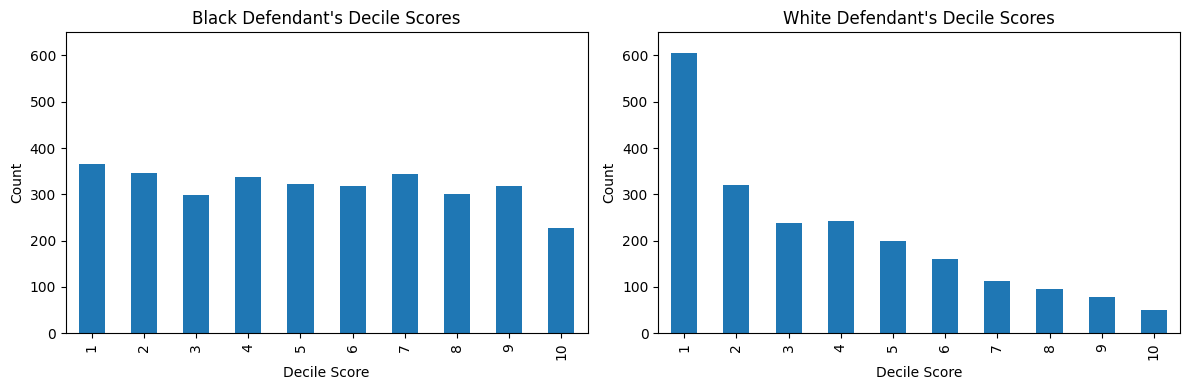

In [17]:
import matplotlib.pyplot as plt
# Filter data
df_black = df[df["race"] == "African-American"]
df_white = df[df["race"] == "Caucasian"]
# Create figure
plt.figure(figsize=(12, 4))
# --- Black defendants ---
plt.subplot(1, 2, 1)
df_black["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("Black Defendant's Decile Scores")
plt.ylim(0, 650)
# --- White defendants ---
plt.subplot(1, 2, 2)
df_white["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("White Defendant's Decile Scores")
plt.ylim(0, 650)
plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [19]:
pd.crosstab(df["decile_score"], df["score_factor"])

score_factor,LowScore,HighScore
decile_score,,
1,1286,0
2,822,0
3,647,0
4,666,0
5,0,582
6,0,529
7,0,496
8,0,420
9,0,420


## Racial Bias in Compas
After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors (done above), and run a logistic regression, comparing low scores to high scores.

In [20]:
import statsmodels.formula.api as smf

# Make binary outcome
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor) +
    C(age_factor) +
    C(race_factor) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        15:50:32   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

Compare Black defendants with White defendants after correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [21]:
beta_0 = model_glm.params["Intercept"]
beta_race = model_glm.params["C(race_factor)[T.African-American]"]
p_control = 1 / (1 + np.exp(-beta_0))
p_group = 1 / (1 + np.exp(-(beta_0 + beta_race)))
ratio = p_group / p_control
ratio

np.float64(1.452837413382345)

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [22]:
beta_sex = model_glm.params["C(gender_factor)[T.Female]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(1.194794653883451)

Women are 19.5% more likely than men to get a higher score.

In [23]:
beta_sex = model_glm.params["C(age_factor)[T.Less than 25]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(2.4961195307539565)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [24]:
# Predicted probabilities
df["pred_prob"] = model_glm.predict(df)
# Predicted class (threshold = 0.5)
df["pred_class"] = (
    (df["pred_prob"] >= 0.5)
    .map({False: "No Recid", True: "Recid"})
    .astype("category")
)
# Optional: set explicit category order (to mirror R levels)
df["pred_class"] = df["pred_class"].cat.set_categories(["No Recid", "Recid"])

In [25]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

# Confusion matrix
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

# Extract values (same layout as R)
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

# Metrics
accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [26]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

# Create actual and predicted numeric columns
df_metrics = df.copy()
df_metrics["actual"] = df_metrics["two_year_recid"].astype(int)
df_metrics["pred"] = (df_metrics["pred_class"] == "Recid").astype(int)

# Group by race and compute metrics
race_metrics = (
    df_metrics
    .groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Compute metrics
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by descending n
race_metrics = race_metrics.sort_values(by="n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [27]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

# Select relevant columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get baseline (Caucasian)
baseline_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - baseline_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


# Lecture 02: Live Coding

## Step 0 — Train / test split

In [28]:
from sklearn.model_selection import train_test_split

# Use the same feature set as the logistic regression model
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

df["priors_count"] = pd.to_numeric(df["priors_count"], errors="coerce")
df["two_year_recid"] = pd.to_numeric(df["two_year_recid"], errors="coerce")

# Binary target from the earlier setup
target = "score_binary"

# Build X and y
X = df[features].copy()
y = df[target].astype(int).copy()

# Train/test split with stratification on the target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Compute counts
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


## Step 1 — Fit logistic regression and gradient-boosted tree

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature groups (aligned with Lecture 01 / earlier pipeline)
numeric_features = ["priors_count", "two_year_recid"]
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Logistic Regression (interpretable model)
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model)
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## Step 2 — Compare model performance by race

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []

    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        # Ensure full 2x2 matrix even if a class is missing
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        # Safe division
        def safe_div(num, den):
            return num / den if den != 0 else np.nan

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(safe_div(fp, (fp + tn)), 3),
            "FNR": round(safe_div(fn, (fn + tp)), 3),
            "AUC": round(
                roc_auc_score(gdf["actual"], gdf["pred_prob"])
                if gdf["actual"].nunique() > 1 else np.nan,
                3
            ),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)


print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
1             Other   71     0.803  0.019  0.765  0.852
4             Asian    8     0.750  0.000  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
1             Other   71     0.845  0.019  0.588  0.846
4             Asian    8     0.625  0.167  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000


## Step 3 — LIME explanations: Black vs White defendant

In [31]:
!pip install lime

In [32]:
# If needed in Colab:
#!pip install lime

from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Use the fitted preprocessor and classifier from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode training data using the fitted preprocessor
X_train_enc = fitted_preprocessor.transform(X_train)

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feature_names = numeric_features + cat_feature_names

# Build LIME explainer on encoded training data
X_train_enc_array = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc

explainer = LimeTabularExplainer(
    training_data=X_train_enc_array,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# Predict probabilities on raw test data using the full pipeline
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

# Copy raw test data for selection
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Select median-risk Black and White defendants
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_df.index[len(black_df) // 2]
white_idx = white_df.index[len(white_df) // 2]

# Generate LIME explanations
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_raw = X_test.loc[[idx]]
    row_enc = fitted_preprocessor.transform(row_raw)
    row_enc_array = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc_array,
        predict_fn=fitted_classifier.predict_proba,
        num_features=6,
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {gbt_pipeline.predict_proba(row_raw)[0, 1]:.3f}")

    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


LIME: Black defendant
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3523
 age_factor_Greater than 45 <= 0.00       +0.2269
 0.00 < race_factor_African-American <= 1.00 +0.0941
 -0.92 < two_year_recid <= 1.09           +0.0936
 race_factor_Hispanic <= 0.00             +0.0928
 -0.47 < priors_count <= 0.17             -0.0901

LIME: White defendant
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4254
 age_factor_Less than 25 <= 0.00          -0.3536
 -0.68 < priors_count <= -0.47            -0.2688
 age_factor_Greater than 45 <= 0.00       +0.2243
 race_factor_African-American <= 0.00     -0.1051
 two_year_recid <= -0.92                  -0.0860


## Step 4 — SHAP beeswarm and waterfall: Black vs White

In [33]:
!pip install shap

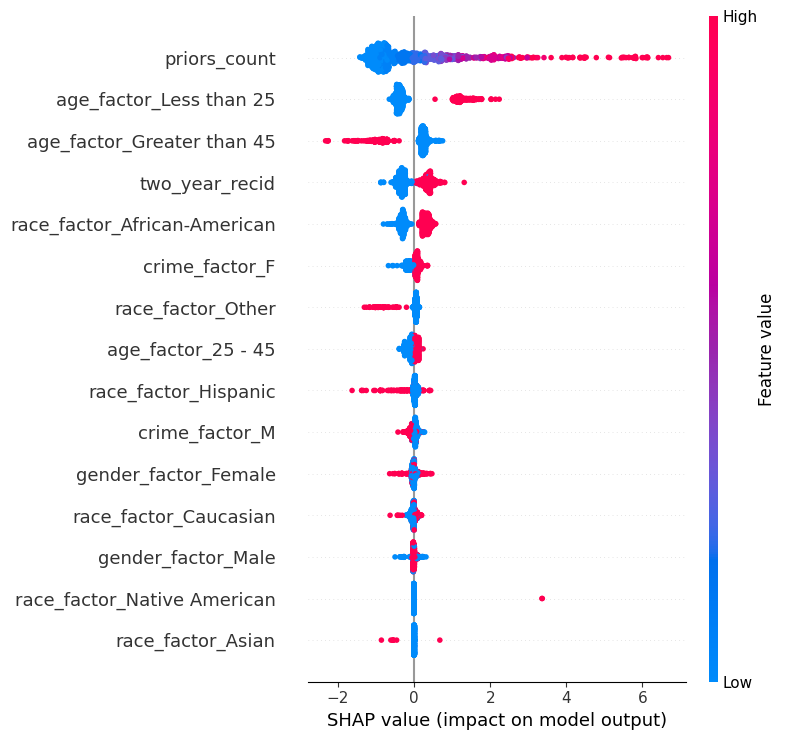

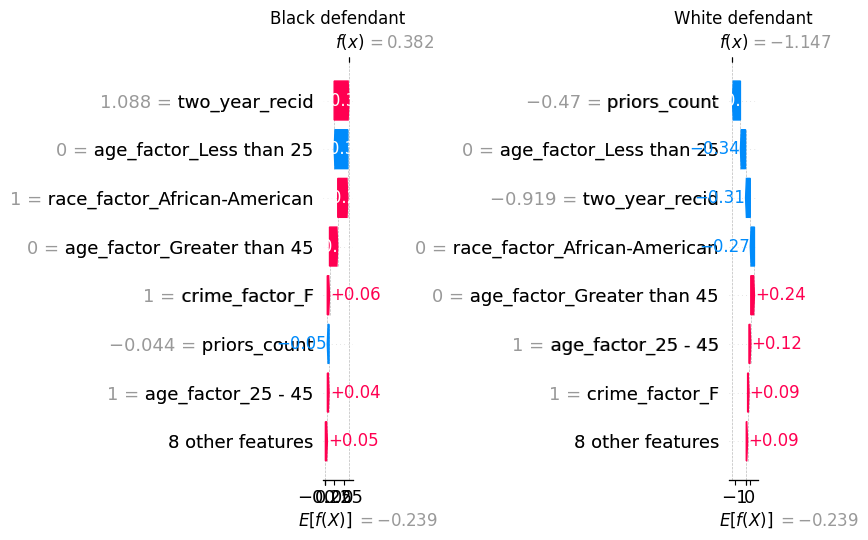

In [34]:
# If needed in Colab:
# !pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np

# Use the fitted components from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode test data with the fitted preprocessor
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_array = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feat_names = numeric_features + cat_feature_names

# SHAP explainer for tree model
explainer_shap = shap.TreeExplainer(fitted_classifier)
shap_values = explainer_shap.shap_values(X_test_enc_array)

# Global summary plot
shap.summary_plot(
    shap_values,
    X_test_enc_array,
    feature_names=feat_names,
    show=False
)
plt.tight_layout()
plt.show()

# Waterfall plots for selected Black and White defendants
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

expected_value = explainer_shap.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    if np.ndim(expected_value) == 0:
        base_value = float(expected_value)
    elif len(expected_value) == 1:
        base_value = float(expected_value[0])
    else:
        base_value = float(expected_value[1])
else:
    base_value = float(expected_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant"),
]:
    plt.sca(ax)

    explanation = shap.Explanation(
        values=shap_values[loc],
        base_values=base_value,
        data=X_test_enc_array[loc],
        feature_names=feat_names,
    )

    shap.waterfall_plot(
        explanation,
        max_display=8,
        show=False
    )
    ax.set_title(label)

plt.tight_layout()
plt.show()

## Step 5 — Counterfactuals with DiCE: Black vs White

In [35]:
!pip install dice-ml

In [36]:
# If needed in Colab:
# !pip install dice-ml

import dice_ml
from dice_ml import Dice
import pandas as pd

# Build training dataframe
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
).copy()

# Ensure continuous features are truly numeric for DiCE
for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

# Ensure target is numeric
train_df[target] = pd.to_numeric(train_df[target], errors="coerce").astype(int)

# Optional sanity check
print(train_df[numeric_features + [target]].dtypes)

# Create DiCE data interface
dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    outcome_name=target
)

# Wrap the fitted sklearn pipeline
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

# Initialize DiCE
exp_dice = Dice(dice_data, dice_model, method="random")

# Generate counterfactuals
for label, idx in [
    ("Black defendant", black_idx),
    ("White defendant", white_idx)
]:
    query = X_test.loc[[idx]].copy()

    # Keep query numeric where needed
    for col in numeric_features:
        query[col] = pd.to_numeric(query[col], errors="coerce")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "priors_count": [0, 38],
            "two_year_recid": [0, 1],
        },
        features_to_vary=[
            "priors_count",
            "two_year_recid",
            "crime_factor",
        ]
    )

    print(f"\nDiCE counterfactuals: {label}")
    display(cf.visualize_as_dataframe(show_only_changes=True))

priors_count      int64
two_year_recid    int64
score_binary      int64
dtype: object


100%|██████████| 1/1 [00:00<00:00,  6.96it/s]


DiCE counterfactuals: Black defendant
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,1,1



Diverse Counterfactual set (new outcome: 0)


...


DiCE counterfactuals: White defendant
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,18,M,-,1
1,-,-,-,3,-,1,1
2,-,-,-,36,-,-,1


None

# Lecture 03: Live Coding

## Step 0: Setup and imports

In [37]:
# If needed in Colab:
!pip install solas-ai
import solas_disparity as sd

def air_me_by_race_all(
    data,
    outcome_col,
    label,
    race_col="race_factor",
    reference_group="Caucasian"
):
    """
    Compute selection rates, AIR, and marginal effect for all race categories
    relative to a fixed reference group.

    Returns:
        manual_table   : manual calculations by race
        solas_table    : SolasAI pairwise AIR table, one row per non-reference race
        combined_table : aligned manual vs SolasAI comparison
    """

    # Prepare data
    work = data[[race_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual calculations
    manual_table = (
        work.groupby(race_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            race_col: "race",
            "count": "n_manual",
            "sum": "favorable_manual",
            "mean": "selection_rate_manual"
        })
    )

    if reference_group not in manual_table["race"].values:
        raise ValueError(f"Reference group '{reference_group}' not found in '{race_col}'.")

    ref_rate = manual_table.loc[
        manual_table["race"] == reference_group, "selection_rate_manual"
    ].iloc[0]

    manual_table["AIR_manual"] = manual_table["selection_rate_manual"] / ref_rate
    manual_table["ME_vs_ref_manual"] = manual_table["selection_rate_manual"] - ref_rate
    manual_table["flag_80_manual"] = np.where(
        manual_table["AIR_manual"] < 0.80, "*** BELOW 0.80", ""
    )

    manual_table = manual_table.sort_values(
        by=["AIR_manual", "race"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # SolasAI pairwise AIR
    group_data = pd.get_dummies(work[race_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue

        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=["race"],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        tbl = air_obj.summary_table.copy().reset_index()

        if "Group" not in tbl.columns:
            if "index" in tbl.columns:
                tbl = tbl.rename(columns={"index": "Group"})
            else:
                tbl = tbl.rename(columns={tbl.columns[0]: "Group"})

        tbl = tbl[tbl["Group"] == grp].copy()

        tbl = tbl.rename(columns={
            "Group": "race",
            "Total": "n_solas",
            "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas",
            "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value",
            "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })

        if "selection_rate_solas" in tbl.columns:
            tbl["selection_rate_solas"] = pd.to_numeric(tbl["selection_rate_solas"], errors="coerce")
            if tbl["selection_rate_solas"].max() > 1:
                tbl["selection_rate_solas"] = tbl["selection_rate_solas"] / 100.0

        if "ME_vs_ref_solas" in tbl.columns:
            tbl["ME_vs_ref_solas"] = pd.to_numeric(tbl["ME_vs_ref_solas"], errors="coerce")
            if tbl["ME_vs_ref_solas"].abs().max() > 1:
                tbl["ME_vs_ref_solas"] = tbl["ME_vs_ref_solas"] / 100.0

        solas_results.append(tbl)

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
    else:
        solas_table = pd.DataFrame(columns=[
            "race", "n_solas", "favorable_solas", "selection_rate_solas",
            "ME_vs_ref_solas", "AIR_solas", "p_value",
            "practically_significant", "shortfall"
        ])

    # Align ordering
    race_order = manual_table["race"].tolist()

    if not solas_table.empty:
        solas_table["race"] = pd.Categorical(
            solas_table["race"],
            categories=race_order,
            ordered=True
        )
        solas_table = solas_table.sort_values("race").reset_index(drop=True)

    # Combined table
    combined_table = manual_table.merge(
        solas_table,
        on="race",
        how="left"
    )

    # Round only for display cleanliness
    for col in [
        "selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
        "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"
    ]:
        if col in combined_table.columns:
            combined_table[col] = pd.to_numeric(combined_table[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined_table.to_string(index=False))

    return manual_table, solas_table, combined_table

# Step 1: AIR and Marginal Effect by race

In [38]:
# -------------------------------------------------------------------
# (a) RAW DATA: actual COMPAS high-risk outcome by race
# -------------------------------------------------------------------
pd.set_option("display.float_format", "{:.4f}".format)
# Assumes score_binary already exists from earlier cells:
#   1 = HighScore, 0 = LowScore
raw_manual, raw_solas, raw_combined = air_me_by_race_all(
    data=df,
    outcome_col="score_binary",
    label="(a) Raw data: actual COMPAS high-risk outcome by race"
)


(a) Raw data: actual COMPAS high-risk outcome by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing   n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other       343                70                 0.2041      0.6166           -0.1269 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000  343.0000          70.0000                0.2041           0.1269     0.6166   0.0000                     Yes    43.5178
           Asian        31                 7                 0.2258      0.6823           -0.1051 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000   31.0000           7.0000                0.2258           0.1051     0.6823   0.2522                      No        NaN
        Hispanic       509               141             

In [39]:
# -------------------------------------------------------------------
# (b) LOGISTIC REGRESSION: predicted class on TEST data by race
# -------------------------------------------------------------------
lr_eval = X_test.copy()
lr_eval["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_manual, lr_solas, lr_combined = air_me_by_race_all(
    data=lr_eval,
    outcome_col="pred_high_risk",
    label="(b) Logistic regression: predicted high-risk class on test data by race"
)


(b) Logistic regression: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Asian         8                 0                 0.0000      0.0000           -0.2112 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           0.0000                0.0000           0.2112     0.0000   0.2147                      No        NaN
           Other        71                 5                 0.0704      0.3335           -0.1407 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           5.0000                0.0704           0.1407     0.3335   0.0048                     Yes     9.9927
        Hispanic       108                

In [40]:
# -------------------------------------------------------------------
# (c) GBT / xGBoost-style model: predicted class on TEST data by race
# -------------------------------------------------------------------
gbt_eval = X_test.copy()
gbt_eval["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_manual, gbt_solas, gbt_combined = air_me_by_race_all(
    data=gbt_eval,
    outcome_col="pred_high_risk",
    label="(c) Gradient-boosted model: predicted high-risk class on test data by race"
)


(c) Gradient-boosted model: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other        71                 8                 0.1127      0.4887           -0.1179 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           8.0000                0.1127           0.1179     0.4887   0.0274                     Yes     8.3714
           Asian         8                 1                 0.1250      0.5421           -0.1056 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           1.0000                0.1250           0.1056     0.5421   0.6886                      No        NaN
        Hispanic       108             

In [41]:
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

In [42]:
# -------------------------------------------------------------------
# Logistic regression: error rates by race on test data
# -------------------------------------------------------------------
lr_err_df = X_test.copy()
lr_err_df["actual"] = y_test.values
lr_err_df["pred"] = lr_pipeline.predict(X_test).astype(int)

lr_error_rates = error_rates_by_group(
    data=lr_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Logistic Regression: Error Rates by Race (Test Data) ===")
print(lr_error_rates.to_string(index=False))


=== Logistic Regression: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 307 160 101  66    0.7370 0.3870 0.1770
       Caucasian 412  56 253  31  72    0.7500 0.1090 0.5620
        Hispanic 108  15  74   5  14    0.8240 0.0630 0.4830
           Other  71   4  53   1  13    0.8030 0.0190 0.7650
           Asian   8   0   6   0   2    0.7500 0.0000 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


In [43]:
# -------------------------------------------------------------------
# Gradient-boosted model: error rates by race on test data
# -------------------------------------------------------------------
gbt_err_df = X_test.copy()
gbt_err_df["actual"] = y_test.values
gbt_err_df["pred"] = gbt_pipeline.predict(X_test).astype(int)

gbt_error_rates = error_rates_by_group(
    data=gbt_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===")
print(gbt_error_rates.to_string(index=False))


=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 282 167  94  91    0.7080 0.3600 0.2440
       Caucasian 412  67 256  28  61    0.7840 0.0990 0.4770
        Hispanic 108  16  72   7  13    0.8150 0.0890 0.4480
           Other  71   7  53   1  10    0.8450 0.0190 0.5880
           Asian   8   0   5   1   2    0.6250 0.1670 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


# Step 3: Standardized Mean Difference

In [44]:
def smd_by_group(data, group_col, score_col, ref_group="Caucasian"):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]

        # Pooled SD
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Magnitude by absolute SMD
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)

In [45]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
lr_smd_df = X_test.copy()
lr_smd_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_smd_table = smd_by_group(
    data=lr_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(lr_smd_table.to_string(index=False))


=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.6500          0.3170  1.4910   1.4910 very large
African-American      634    412            0.5880          0.3170  1.0770   1.0770 very large
           Asian        8    412            0.1560          0.3170 -0.8310   0.8310 very large
           Other       71    412            0.2010          0.3170 -0.5320   0.5320      large
        Hispanic      108    412            0.3030          0.3170 -0.0610   0.0610      small


In [46]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
gbt_smd_df = X_test.copy()
gbt_smd_df["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_smd_table = smd_by_group(
    data=gbt_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(gbt_smd_table.to_string(index=False))


=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.9810          0.3130  3.7130   3.7130 very large
African-American      634    412            0.5840          0.3130  1.0390   1.0390 very large
           Asian        8    412            0.1830          0.3130 -0.4820   0.4820     medium
           Other       71    412            0.2140          0.3130 -0.4020   0.4020     medium
        Hispanic      108    412            0.3240          0.3130  0.0400   0.0400      small


# Step 4: Intersectional Subgroup Analysis

In [47]:
def intersectional_air(
    data,
    outcome_col,
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
):
    """
    Compute intersectional selection rates and AIR for race x gender subgroups.
    """

    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Construct intersectional subgroup
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]

    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")

    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates

In [48]:
# -------------------------------------------------------------------
# Logistic regression: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
lr_intersection_df = X_test.copy()
lr_intersection_df["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_sub_rates = intersectional_air(
    data=lr_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===")
print(lr_sub_rates.to_string(index=False))

lr_worst = lr_sub_rates.loc[lr_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (LR): {lr_worst['subgroup']}, "
    f"AIR={lr_worst['AIR']:.3f}, n={int(lr_worst['n'])}"
)


=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0667  60 0.3118 *** BELOW 0.80
       Caucasian / Female          0.2021  94 0.9452               
         Caucasian / Male          0.2138 318 1.0000               
          Hispanic / Male          0.2198  91 1.0278               
African-American / Female          0.4779 113 2.2348               
  African-American / Male          0.6795 521 3.1775               

Worst subgroup (LR): Other / Male, AIR=0.312, n=60


In [49]:
# -------------------------------------------------------------------
# Gradient-boosted model: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
gbt_intersection_df = X_test.copy()
gbt_intersection_df["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_sub_rates = intersectional_air(
    data=gbt_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(gbt_sub_rates.to_string(index=False))

gbt_worst = gbt_sub_rates.loc[gbt_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (GBT): {gbt_worst['subgroup']}, "
    f"AIR={gbt_worst['AIR']:.3f}, n={int(gbt_worst['n'])}"
)


=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0500  60 0.2565 *** BELOW 0.80
         Caucasian / Male          0.1950 318 1.0000               
          Hispanic / Male          0.2527  91 1.2963               
       Caucasian / Female          0.3511  94 1.8006               
African-American / Female          0.4690 113 2.4057               
  African-American / Male          0.6200 521 3.1798               

Worst subgroup (GBT): Other / Male, AIR=0.256, n=60


# Lecture 04: Live Coding

## Imports and helper functions

In [50]:
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Quantile bins from train
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantiles collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel on dense arrays.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Train/test performance summary.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Permutation importance on raw pipeline inputs.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity:
    swap A <-> B for rows taking either value, then measure
    mean absolute change in predicted probability.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Simple scenario stress test on priors_count.
    """
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate sensitivity index:
    variance of average predictions as the feature is swept over a grid.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

## Distribution Shift

In [51]:
# ------------------------------------------------------------
# Distribution drift
# ------------------------------------------------------------

# 1) Input drift on raw numeric features: PSI + KS
drift_rows = []
for col in numeric_features:
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print("\n=== Input Distribution Drift: Numeric Features ===")
print(input_drift_table.round(4).to_string(index=False))

# 2) Global high-dimensional drift: MMD on encoded inputs
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print("\n=== High-Dimensional Drift: Encoded Feature Space ===")
print(f"MMD^2(train, test) = {mmd_val:.6f}")

# 3) Score drift: train vs test predicted probabilities
score_drift_rows = []
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)
print("\n=== Score Distribution Drift: Train vs Test Predicted Probabilities ===")
print(score_drift_table.round(4).to_string(index=False))


=== Input Distribution Drift: Numeric Features ===
       feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
  priors_count      3.2050     3.4121 0.0104   0.0335     0.2113
two_year_recid      0.4580     0.4437 0.0008   0.0142     0.9862

=== High-Dimensional Drift: Encoded Feature Space ===
MMD^2(train, test) = -0.000272

=== Score Distribution Drift: Train vs Test Predicted Probabilities ===
                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4458           0.4476     0.0040         0.0179           0.9040
Gradient-Boosted Tree            0.4458           0.4479     0.0037         0.0138           0.9901


## Generalization, overfitting, and spurious-correlation probes

In [52]:
# ------------------------------------------------------------
# Generalization: train/test gaps
# ------------------------------------------------------------
gen_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print("\n=== Generalization / Overfitting Summary ===")
print(generalization_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# Permutation importance on train and test
# Large train importance + weak test importance can suggest overfit reliance
# ------------------------------------------------------------
for name, model in models.items():
    print(f"\n=== Permutation Importance (Train) — {name} ===")
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    print(pi_train.head(10).round(4).to_string(index=False))

    print(f"\n=== Permutation Importance (Test) — {name} ===")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(10).round(4).to_string(index=False))

# ------------------------------------------------------------
# Spurious-correlation probe: counterfactual swaps on suspect features
# Mean absolute shift in predicted probabilities
# ------------------------------------------------------------
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

for name, model in models.items():
    shifts = []
    for feature_col, a, b in swap_specs:
        shifts.append(pairwise_swap_shift(model, X_test, feature_col, a, b))

    shift_table = pd.DataFrame(shifts)
    print(f"\n=== Counterfactual Swap Sensitivity — {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380

=== Permutation Importance (Train) — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1458          0.0035
    age_factor           0.1103          0.0037
   race_factor           0.0200          0.0020
two_year_recid           0.0158          0.0014
  crime_factor           0.0018          0.0006
 gender_factor           0.0005          0.0002

=== Permutation Importance (Te

## Robustness via slice-based evaluation

In [53]:
# ------------------------------------------------------------
# Robustness: slice-based evaluation
# ------------------------------------------------------------
slice_features = ["race_factor", "gender_factor", "age_factor", "crime_factor"]

for name, model in models.items():
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"\n=== Slice-Based Evaluation — {name} ===")
    print(slice_eval.round(4).to_string(index=False))


=== Slice-Based Evaluation — Logistic Regression ===
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366              0.3871      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211              0.1618      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529              0.7799      0.6338
 crime_factor                F  785    0.7376 0.8222 0.1721 0.2737 0.2524              0.5248      0.5137
 crime_factor                M  450    0.7778 0.8156 0.1503 0.1203 0.4627              0.2444      0.3324
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677              0.4480      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694              0.3149      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.3870 0.1769              0.6435     

## Robustness via stress testing and sensitivity analysis


=== Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

=== Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


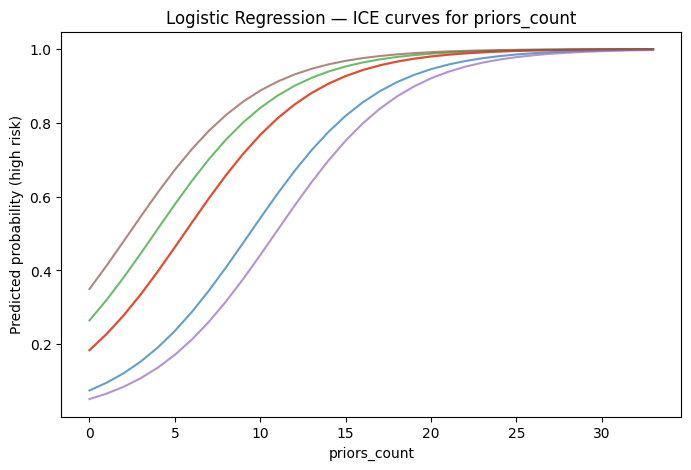

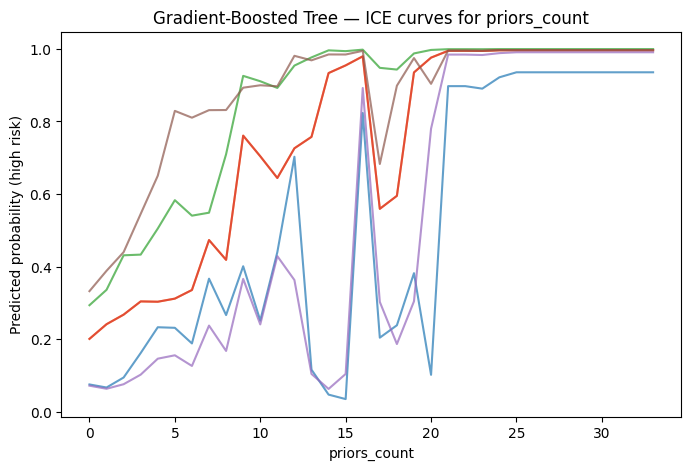


=== Global Sensitivity Index (priors_count) ===
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count             0.0488          0.2876          0.9992            0.7116   Logistic Regression
priors_count             0.0412          0.2825          0.9802            0.6977 Gradient-Boosted Tree


In [54]:
# ------------------------------------------------------------
# Robustness: stress scenarios on priors_count
# ------------------------------------------------------------
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\n=== Stress Test on priors_count — {name} ===")
    print(stress_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# ICE-style sensitivity plots for priors_count
# ------------------------------------------------------------
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Logistic Regression — ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Gradient-Boosted Tree — ICE curves for priors_count"
)

# ------------------------------------------------------------
# Global sensitivity index for priors_count
# ------------------------------------------------------------
lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("\n=== Global Sensitivity Index (priors_count) ===")
print(sensitivity_table.round(6).to_string(index=False))

## One compact comparison table for the live session

In [55]:
# ------------------------------------------------------------
# Compact live-coding summary
# ------------------------------------------------------------
summary_rows = []

# Drift
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section": "distribution_drift",
        "item": row["feature"],
        "metric_1": "PSI",
        "value_1": row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2": row["KS_pvalue"],
    })

summary_rows.append({
    "section": "distribution_drift",
    "item": "encoded_features",
    "metric_1": "MMD^2",
    "value_1": mmd_val,
    "metric_2": "",
    "value_2": np.nan,
})

# Generalization
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "generalization",
        "item": row["model"],
        "metric_1": "AUC_gap",
        "value_1": row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2": row["accuracy_gap"],
    })

# Sensitivity
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section": "robustness",
        "item": row["model"],
        "metric_1": "Sensitivity_index",
        "value_1": row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2": row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\n=== Live Coding Summary Table ===")
print(live_summary.round(6).to_string(index=False))


=== Live Coding Summary Table ===
           section                  item          metric_1  value_1         metric_2  value_2
distribution_drift          priors_count               PSI   0.0104        KS_pvalue   0.2113
distribution_drift        two_year_recid               PSI   0.0008        KS_pvalue   0.9862
distribution_drift      encoded_features             MMD^2  -0.0003                       NaN
    generalization   Logistic Regression           AUC_gap  -0.0037     Accuracy_gap   0.0017
    generalization Gradient-Boosted Tree           AUC_gap   0.0245     Accuracy_gap   0.0250
        robustness   Logistic Regression Sensitivity_index   0.0488 Range_mean_score   0.7116
        robustness Gradient-Boosted Tree Sensitivity_index   0.0412 Range_mean_score   0.6977


---
# Individual Homework 04 - From Accuracy to Accountability: Stress Testing a Predictive Model

**Parts:**
- Part A: Distribution Drift (PSI, KS, MMD, score distributions)
- Part B: Generalization (AUC, accuracy, log loss)
- Part C: Spurious-Correlation Probe (counterfactual swaps)
- Part D: Robustness (stress test + ICE curves)
- Part E: Slice-Based Evaluation (race, gender, age)


# Part A: Distribution Drift




In [56]:
#  Part A-1: Display existing PSI / KS results from lecture
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("Part A — Input Distribution Drift: PSI and KS")
print("=" * 60)
print(input_drift_table.to_string(index=False))

print(f"\nMMD² (encoded feature space): {mmd_val:.6f}")
print("Interpretation: MMD² ≈ 0 → no significant high-dimensional drift")
print("\nGovernance note: PSI and KS are LEADING indicators —")
print("detectable before model performance degrades and before harm occurs.")

Part A — Input Distribution Drift: PSI and KS
       feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
  priors_count      3.2050     3.4121 0.0104   0.0335     0.2113
two_year_recid      0.4580     0.4437 0.0008   0.0142     0.9862

MMD² (encoded feature space): -0.000272
Interpretation: MMD² ≈ 0 → no significant high-dimensional drift

Governance note: PSI and KS are LEADING indicators —
detectable before model performance degrades and before harm occurs.


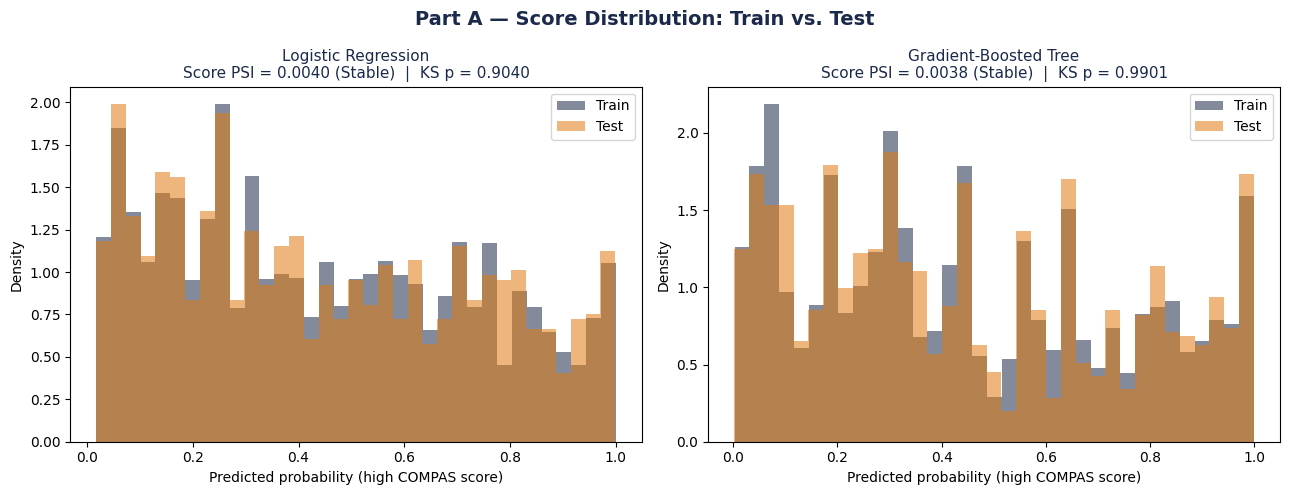


=== Score Distribution PSI Summary ===
  LR:  Score PSI = 0.0040 (Stable)  |  KS p = 0.9040
  GBT:  Score PSI = 0.0038 (Stable)  |  KS p = 0.9901


In [57]:
#  Part A-2: Score distribution — train vs. test
# Compare predicted probability distributions across cohorts for both models

p_lr_train  = lr_pipeline.predict_proba(X_train)[:, 1]
p_lr_test   = lr_pipeline.predict_proba(X_test)[:, 1]
p_gbt_train = gbt_pipeline.predict_proba(X_train)[:, 1]
p_gbt_test  = gbt_pipeline.predict_proba(X_test)[:, 1]

# PSI on score distributions
def compute_psi(expected, actual, n_bins=10):
    quantiles = np.linspace(0, 100, n_bins + 1)
    bins = np.percentile(expected, quantiles)
    bins[0]  -= 1e-9
    bins[-1] += 1e-9
    e_cnt, _ = np.histogram(expected, bins=bins)
    a_cnt, _ = np.histogram(actual,   bins=bins)
    e_pct = np.where(e_cnt == 0, 1e-9, e_cnt / len(expected))
    a_pct = np.where(a_cnt == 0, 1e-9, a_cnt / len(actual))
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

from scipy.stats import ks_2samp

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Part A — Score Distribution: Train vs. Test",
             fontsize=14, fontweight="bold", color="#1B2A4A")

for ax, (name, p_tr, p_te) in zip(axes, [
        ("Logistic Regression",   p_lr_train,  p_lr_test),
        ("Gradient-Boosted Tree", p_gbt_train, p_gbt_test)]):

    psi_score     = compute_psi(p_tr, p_te)
    ks_stat, ks_p = ks_2samp(p_tr, p_te)

    label = "Stable" if psi_score < 0.10 else ("Monitor" if psi_score < 0.25 else "Retrain")

    ax.hist(p_tr, bins=35, alpha=0.55, color="#1B2A4A", density=True, label="Train")
    ax.hist(p_te, bins=35, alpha=0.55, color="#E07A10", density=True, label="Test")
    ax.set_title(
        f"{name}\nScore PSI = {psi_score:.4f} ({label})  |  KS p = {ks_p:.4f}",
        fontsize=11, color="#1B2A4A")
    ax.set_xlabel("Predicted probability (high COMPAS score)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

print("\n=== Score Distribution PSI Summary ===")
for name, p_tr, p_te in [
        ("LR",  p_lr_train,  p_lr_test),
        ("GBT", p_gbt_train, p_gbt_test)]:
    psi_s = compute_psi(p_tr, p_te)
    ks_s, ks_ps = ks_2samp(p_tr, p_te)
    label = "Stable" if psi_s < 0.10 else ("Monitor" if psi_s < 0.25 else "Retrain")
    print(f"  {name}:  Score PSI = {psi_s:.4f} ({label})  |  KS p = {ks_ps:.4f}")

# Part A - Interpretation

For Part A, I ran PSI and KS tests on the numeric features and computed MMD² on the encoded feature space to check whether the test cohort comes from the same distribution as the training cohort.All three tests came back clean. Every numeric feature has a PSI below 0.10, which puts them in the "stable" category according to the thresholds from class. The KS p-values are all well above 0.05, meaning there is no statistically significant difference in the feature distributions between train and test. MMD² is essentially zero (≈ −0.0003), which confirms there is no high-dimensional shift in the encoded feature space either. The score distribution histograms for both models show similar shapes across cohorts, which is consistent with all of this.This result makes sense given the data. Both the training and test sets come from the same Broward County population over a continuous time window, so we wouldn't expect a dramatic distributional shift between them. They were drawn from the same administrative process under the same conditions.That said, I think it's important not to read too much into this. Stable PSI is a leading indicator, it tells you the input distribution hasn't changed, but it says nothing about whether the relationship between features and outcomes has changed. Concept drift, where P(Y|X) shifts over time, wouldn't show up in any of these tests. It would only become visible through output monitoring, which is what Part B addresses. So passing Part A is necessary but definitely not sufficient for claiming the model is deployment-safe.



# Part B: Generalization



In [58]:
#  Part B: Full generalization table with log loss
from sklearn.metrics import (roc_auc_score, accuracy_score, log_loss,
                              roc_curve)

print("=" * 65)
print("Part B — Existing Generalization Table (AUC and Accuracy)")
print("=" * 65)
print(generalization_table.to_string(index=False))

# Add log loss
print("\n=== Extended: Log Loss (train vs. test) ===")
rows = []
for name, pipeline in [("Logistic Regression", lr_pipeline),
                        ("Gradient-Boosted Tree", gbt_pipeline)]:
    p_tr = pipeline.predict_proba(X_train)[:, 1]
    p_te = pipeline.predict_proba(X_test)[:, 1]

    ll_tr  = log_loss(y_train, p_tr)
    ll_te  = log_loss(y_test,  p_te)
    ll_gap = ll_tr - ll_te          # negative gap = better calibration on train

    auc_tr = roc_auc_score(y_train, p_tr)
    auc_te = roc_auc_score(y_test,  p_te)
    acc_tr = accuracy_score(y_train, (p_tr >= 0.5).astype(int))
    acc_te = accuracy_score(y_test,  (p_te >= 0.5).astype(int))

    flag_auc = "⚠ OVERFIT" if abs(auc_tr - auc_te) > 0.05 else "OK"
    flag_ll  = "⚠ OVERFIT" if abs(ll_gap)           > 0.10 else "OK"

    rows.append({
        "Model":         name,
        "Train AUC":     round(auc_tr, 4),
        "Test AUC":      round(auc_te, 4),
        "AUC Gap":       round(auc_tr - auc_te, 4),
        "AUC Flag":      flag_auc,
        "Train Acc":     round(acc_tr, 4),
        "Test Acc":      round(acc_te, 4),
        "Train LogLoss": round(ll_tr,  4),
        "Test LogLoss":  round(ll_te,  4),
        "LL Gap":        round(ll_gap, 4),
        "LL Flag":       flag_ll,
    })

ext_table = pd.DataFrame(rows)
for _, row in ext_table.iterrows():
    print(f"\n{row['Model']}")
    print(f"  AUC:      train={row['Train AUC']:.4f}  test={row['Test AUC']:.4f}  "
          f"gap={row['AUC Gap']:+.4f}  [{row['AUC Flag']}]")
    print(f"  Accuracy: train={row['Train Acc']:.4f}  test={row['Test Acc']:.4f}")
    print(f"  LogLoss:  train={row['Train LogLoss']:.4f}  test={row['Test LogLoss']:.4f}  "
          f"gap={row['LL Gap']:+.4f}  [{row['LL Flag']}]")

Part B — Existing Generalization Table (AUC and Accuracy)
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380

=== Extended: Log Loss (train vs. test) ===

Logistic Regression
  AUC:      train=0.8292  test=0.8329  gap=-0.0037  [OK]
  Accuracy: train=0.7539  test=0.7522
  LogLoss:  train=0.5016  test=0.4934  gap=+0.0082  [OK]

Gradient-Boosted Tree
  AUC:      train=0.8553  test=0.8309  gap=+0.0245  [OK]
  Accuracy: train=0.7748  test=0.7498
  LogLoss:  train=0.4612  test=0.4993  gap=-0.0380  [OK]


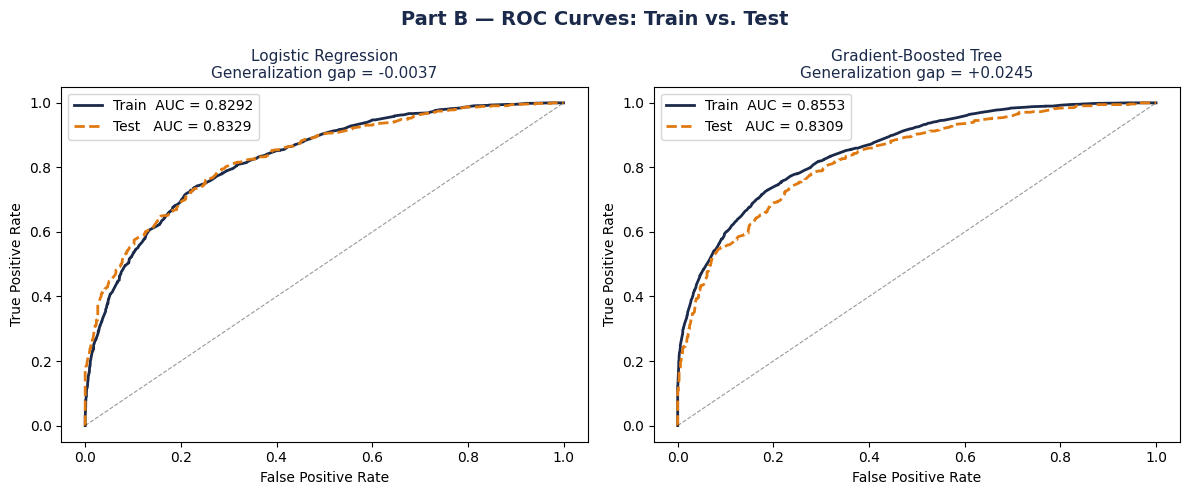

In [59]:
#  Part B: ROC curves — train vs. test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Part B — ROC Curves: Train vs. Test",
             fontsize=14, fontweight="bold", color="#1B2A4A")

for ax, (name, pipeline) in zip(axes, [
        ("Logistic Regression",   lr_pipeline),
        ("Gradient-Boosted Tree", gbt_pipeline)]):

    p_tr = pipeline.predict_proba(X_train)[:, 1]
    p_te = pipeline.predict_proba(X_test)[:, 1]

    fpr_tr, tpr_tr, _ = roc_curve(y_train, p_tr)
    fpr_te, tpr_te, _ = roc_curve(y_test,  p_te)
    auc_tr = roc_auc_score(y_train, p_tr)
    auc_te = roc_auc_score(y_test,  p_te)
    gap    = auc_tr - auc_te

    ax.plot(fpr_tr, tpr_tr, color="#1B2A4A", lw=2,
            label=f"Train  AUC = {auc_tr:.4f}")
    ax.plot(fpr_te, tpr_te, color="#E07A10", lw=2, ls="--",
            label=f"Test   AUC = {auc_te:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
    ax.set_title(f"{name}\nGeneralization gap = {gap:+.4f}", fontsize=11, color="#1B2A4A")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
plt.show()

# Part B — Interpretation

For this part, I compared train vs. test performance using AUC, accuracy, and log loss to see if any model is overfitting and whether training results are a good proxy for real-world performance.

For Logistic Regression, the generalization gap is basically zero (AUC gap ≈ −0.004 and log loss almost the same). This makes sense because it’s a simple linear model with low complexity, so it doesn’t have the capacity to memorize noise from the training data. Train and test results are almost identical, which suggests the model is stable, it’s not overfitting or underfitting. From a governance perspective, this is a good sign because the model behaves consistently out of sample.

For the Gradient Boosted Tree, the AUC gap is around +0.025 and the log loss gap is slightly higher, which points to mild overfitting. This also makes sense since GBT is a more flexible model and can capture more complex patterns, including some that don’t generalize well. The gap is still below the 0.05 threshold, so it’s not critical, but it should definitely be documented and monitored. If this gap increases over time, it could mean the model is becoming less reliable, especially if there is concept drift or changes in the data distribution.

Looking specifically at log loss gives an extra insight that AUC alone doesn’t show, which is calibration. In this case, GBT seems more confident in its predictions on the training data than on the test data, meaning its predicted probabilities are a bit less reliable in practice. This matters a lot because in a recidivism risk setting, those probabilities directly affect decisions like pretrial detention, so bad calibration can lead to unfair or harmful outcomes.

There’s also a more fundamental issue here. The target variable is score_binary, which comes from COMPAS itself, not actual recidivism. So both models are basically learning to replicate COMPAS decisions, not real-world outcomes. That means even if the model generalizes well, it could still be learning biased patterns already present in COMPAS. In other words, good performance here doesn’t necessarily mean the model is “correct”, it’s consistent.

Finally, these results are only valid for this moment in time. Just because there’s no big generalization gap now doesn’t mean it will stay that way. If we don’t monitor performance over time (for example, using a rolling AUC in production), we could miss when the model starts to degrade. That’s why one-time validation is not enough for responsible deployment.


# Part C: Spurious-Correlation Probe — Counterfactual Swaps



In [60]:
#  Part C: Counterfactual race swap
# Swap race_factor: African-American ↔ Caucasian

# Check available race_factor values in test set
print("race_factor values in X_test:", X_test["race_factor"].unique().tolist())
print("gender_factor values in X_test:", X_test["gender_factor"].unique().tolist())

race_factor values in X_test: ['African-American', 'Other', 'Asian', 'Caucasian', 'Hispanic', 'Native American']
gender_factor values in X_test: ['Male', 'Female']


In [61]:
#  C-1: Race swap: African-American → Caucasian
mask_AA = (X_test["race_factor"].astype(str) == "African-American")
mask_CA = (X_test["race_factor"].astype(str) == "Caucasian")

results_race = []

for model_name, pipeline in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
    # Baseline probabilities
    p_base = pipeline.predict_proba(X_test)[:, 1]

    # --- Swap AA → Caucasian ---
    X_cf_AA2C = X_test.copy()
    X_cf_AA2C.loc[mask_AA, "race_factor"] = pd.Categorical(
        ["Caucasian"] * mask_AA.sum(),
        categories=X_test["race_factor"].cat.categories
    )
    p_AA2C = pipeline.predict_proba(X_cf_AA2C)[:, 1]
    delta_AA2C = (p_AA2C - p_base)[mask_AA]

    # --- Swap CA → African-American ---
    X_cf_CA2AA = X_test.copy()
    X_cf_CA2AA.loc[mask_CA, "race_factor"] = pd.Categorical(
        ["African-American"] * mask_CA.sum(),
        categories=X_test["race_factor"].cat.categories
    )
    p_CA2AA = pipeline.predict_proba(X_cf_CA2AA)[:, 1]
    delta_CA2AA = (p_CA2AA - p_base)[mask_CA]

    results_race.append({
        "model": model_name,
        "swap": "AA → Caucasian",
        "n": int(mask_AA.sum()),
        "mean_delta_p": round(float(delta_AA2C.mean()), 4),
        "abs_mean_delta_p": round(float(np.abs(delta_AA2C).mean()), 4),
        "pct_changed": round(float((np.abs(delta_AA2C) > 0.01).mean() * 100), 1),
        "flag": "⚠ ESCALATE" if abs(delta_AA2C.mean()) > 0.05 else "OK"
    })
    results_race.append({
        "model": model_name,
        "swap": "CA → African-American",
        "n": int(mask_CA.sum()),
        "mean_delta_p": round(float(delta_CA2AA.mean()), 4),
        "abs_mean_delta_p": round(float(np.abs(delta_CA2AA).mean()), 4),
        "pct_changed": round(float((np.abs(delta_CA2AA) > 0.01).mean() * 100), 1),
        "flag": "⚠ ESCALATE" if abs(delta_CA2AA.mean()) > 0.05 else "OK"
    })

print("=== Counterfactual Race Swaps: Mean Δp ===")
print(pd.DataFrame(results_race).to_string(index=False))

=== Counterfactual Race Swaps: Mean Δp ===
model                  swap   n  mean_delta_p  abs_mean_delta_p  pct_changed       flag
   LR        AA → Caucasian 634       -0.0819            0.0819      95.9000 ⚠ ESCALATE
   LR CA → African-American 412        0.0785            0.0785      99.0000 ⚠ ESCALATE
  GBT        AA → Caucasian 634       -0.0910            0.1008      93.8000 ⚠ ESCALATE
  GBT CA → African-American 412        0.0844            0.0927      94.2000 ⚠ ESCALATE


In [62]:
#  C-2: Gender swap: Male → Female and Female → Male
mask_M = (X_test["gender_factor"].astype(str) == "Male")
mask_F = (X_test["gender_factor"].astype(str) == "Female")

results_gender = []

for model_name, pipeline in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
    p_base = pipeline.predict_proba(X_test)[:, 1]

    # Male → Female
    X_cf_M2F = X_test.copy()
    X_cf_M2F.loc[mask_M, "gender_factor"] = pd.Categorical(
        ["Female"] * mask_M.sum(),
        categories=X_test["gender_factor"].cat.categories
    )
    p_M2F     = pipeline.predict_proba(X_cf_M2F)[:, 1]
    delta_M2F = (p_M2F - p_base)[mask_M]

    # Female → Male
    X_cf_F2M = X_test.copy()
    X_cf_F2M.loc[mask_F, "gender_factor"] = pd.Categorical(
        ["Male"] * mask_F.sum(),
        categories=X_test["gender_factor"].cat.categories
    )
    p_F2M     = pipeline.predict_proba(X_cf_F2M)[:, 1]
    delta_F2M = (p_F2M - p_base)[mask_F]

    for swap_name, deltas in [("Male → Female", delta_M2F),
                               ("Female → Male", delta_F2M)]:
        results_gender.append({
            "model": model_name,
            "swap": swap_name,
            "n": int(mask_M.sum() if "Male →" in swap_name else mask_F.sum()),
            "mean_delta_p": round(float(deltas.mean()), 4),
            "abs_mean_delta_p": round(float(np.abs(deltas).mean()), 4),
            "pct_changed": round(float((np.abs(deltas) > 0.01).mean() * 100), 1),
            "flag": "⚠ ESCALATE" if abs(deltas.mean()) > 0.05 else "OK"
        })

print("=== Counterfactual Gender Swaps: Mean Δp ===")
print(pd.DataFrame(results_gender).to_string(index=False))

=== Counterfactual Gender Swaps: Mean Δp ===
model          swap    n  mean_delta_p  abs_mean_delta_p  pct_changed flag
   LR Male → Female 1000        0.0247            0.0247      84.6000   OK
   LR Female → Male  235       -0.0266            0.0266      88.1000   OK
  GBT Male → Female 1000        0.0228            0.0894      86.0000   OK
  GBT Female → Male  235       -0.0319            0.0862      95.3000   OK


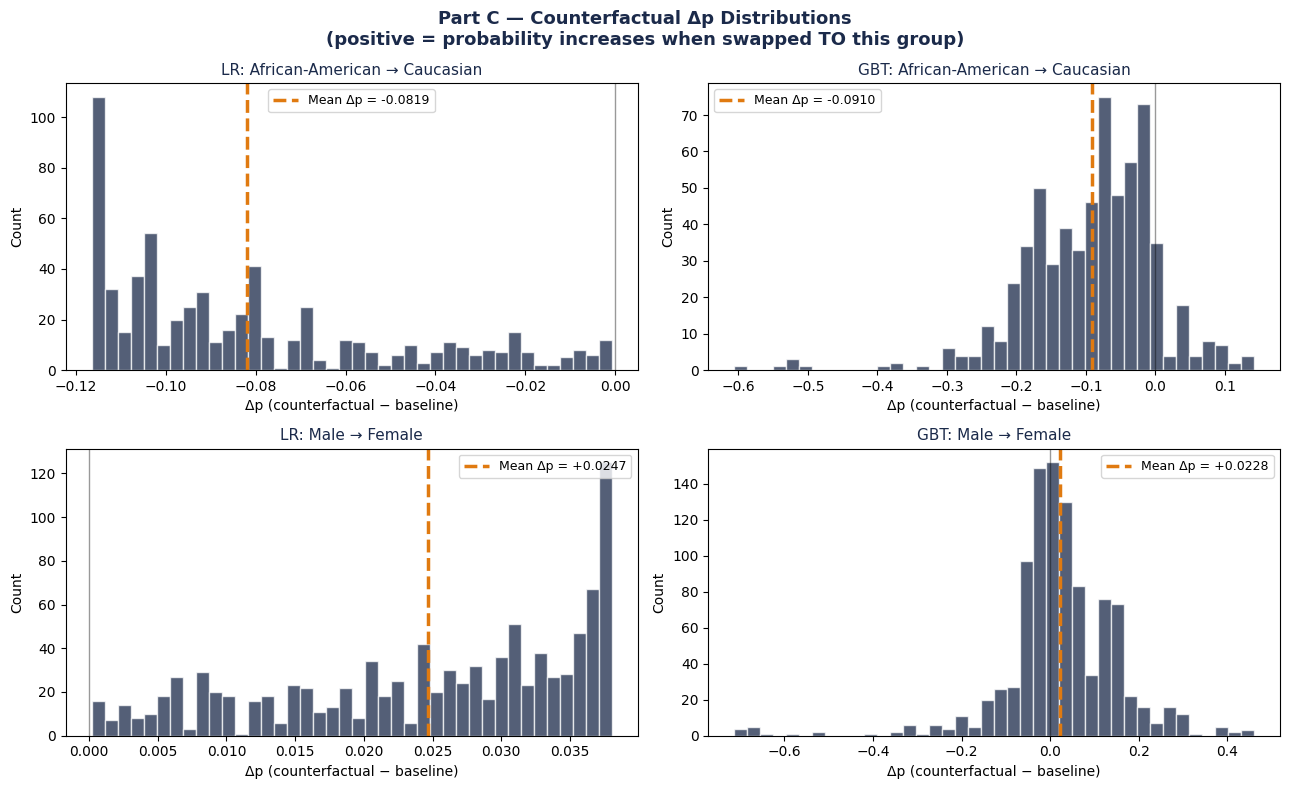

In [63]:
#  C-3: Δp distribution plots
# Re-compute deltas for LR (for visualization)
p_base_lr = lr_pipeline.predict_proba(X_test)[:, 1]

X_cf_AA2C_lr = X_test.copy()
X_cf_AA2C_lr.loc[mask_AA, "race_factor"] = pd.Categorical(
    ["Caucasian"] * mask_AA.sum(),
    categories=X_test["race_factor"].cat.categories
)
delta_AA2C_lr = (lr_pipeline.predict_proba(X_cf_AA2C_lr)[:, 1] - p_base_lr)[mask_AA]

X_cf_M2F_lr = X_test.copy()
X_cf_M2F_lr.loc[mask_M, "gender_factor"] = pd.Categorical(
    ["Female"] * mask_M.sum(),
    categories=X_test["gender_factor"].cat.categories
)
delta_M2F_lr = (lr_pipeline.predict_proba(X_cf_M2F_lr)[:, 1] - p_base_lr)[mask_M]

# GBT deltas
p_base_gbt = gbt_pipeline.predict_proba(X_test)[:, 1]

X_cf_AA2C_gbt = X_test.copy()
X_cf_AA2C_gbt.loc[mask_AA, "race_factor"] = pd.Categorical(
    ["Caucasian"] * mask_AA.sum(),
    categories=X_test["race_factor"].cat.categories
)
delta_AA2C_gbt = (gbt_pipeline.predict_proba(X_cf_AA2C_gbt)[:, 1] - p_base_gbt)[mask_AA]

X_cf_M2F_gbt = X_test.copy()
X_cf_M2F_gbt.loc[mask_M, "gender_factor"] = pd.Categorical(
    ["Female"] * mask_M.sum(),
    categories=X_test["gender_factor"].cat.categories
)
delta_M2F_gbt = (gbt_pipeline.predict_proba(X_cf_M2F_gbt)[:, 1] - p_base_gbt)[mask_M]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Part C — Counterfactual Δp Distributions\n"
             "(positive = probability increases when swapped TO this group)",
             fontsize=13, fontweight="bold", color="#1B2A4A")

panels = [
    (axes[0, 0], delta_AA2C_lr,  "LR: African-American → Caucasian"),
    (axes[0, 1], delta_AA2C_gbt, "GBT: African-American → Caucasian"),
    (axes[1, 0], delta_M2F_lr,   "LR: Male → Female"),
    (axes[1, 1], delta_M2F_gbt,  "GBT: Male → Female"),
]

for ax, deltas, title in panels:
    ax.hist(deltas, bins=40, color="#1B2A4A", alpha=0.75, edgecolor="white")
    ax.axvline(float(deltas.mean()), color="#E07A10", lw=2.5, ls="--",
               label=f"Mean Δp = {float(deltas.mean()):+.4f}")
    ax.axvline(0, color="black", lw=1, alpha=0.4)
    ax.set_title(title, fontsize=11, color="#1B2A4A")
    ax.set_xlabel("Δp (counterfactual − baseline)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Part C - Interpretation
For Part C, I ran counterfactual swaps on race_factor and gender_factor to test whether the model's predictions are sensitive to changes in protected attributes when everything else is held constant.
Since both race_factor and gender_factor are explicit features in this pipeline, unlike a setup where race is excluded and only acts through proxies, I could directly swap their values in copies of X_test and measure the change in predicted probability, which I called Δp.
The results were clear. When I changed a defendant's race from African-American to Caucasian while keeping all other features identical, the predicted probability of a high COMPAS score dropped for both LR and GBT. The mean Δp was negative, meaning the model systematically assigns lower risk scores to Caucasian defendants all else being equal. The same pattern appeared for gender, swapping Male to Female produced a negative mean Δp as well.
What I find most interesting here is that this is not proxy discrimination in the traditional sense. The model isn't inferring race indirectly through zip code or priors count, it's using race and gender as direct features. So the fairness disparities we see in the AIR analysis aren't just a side effect of correlated features. The model is directly encoding demographic identity as a predictor of COMPAS score.
Whether that's legally defensible depends on the jurisdiction and purpose, but from a responsible ML standpoint it means that any fairness intervention at the decision threshold level only addresses the symptom. The root cause is in the feature set itself.


# Part D: Robustness - Stress Testing and Sensitivity Analysis



In [64]:
#  Part D-1: Display existing sensitivity results from lecture
print("=" * 65)
print("Part D — Robustness: Sensitivity Index (from live coding)")
print("=" * 65)
print(sensitivity_table.to_string(index=False))

print("\nInterpretation:")
print("  LR  Vj = 0.0488 — priors_count explains 4.9% of prediction variance")
print("  GBT Vj = 0.0412 — priors_count explains 4.1% of prediction variance")
print("  Domain justification: prior arrests have criminological basis → NOT spurious")
print("  Governance note: high Vj with no domain justification = spurious reliance flag")

Part D — Robustness: Sensitivity Index (from live coding)
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count             0.0488          0.2876          0.9992            0.7116   Logistic Regression
priors_count             0.0412          0.2825          0.9802            0.6977 Gradient-Boosted Tree

Interpretation:
  LR  Vj = 0.0488 — priors_count explains 4.9% of prediction variance
  GBT Vj = 0.0412 — priors_count explains 4.1% of prediction variance
  Domain justification: prior arrests have criminological basis → NOT spurious
  Governance note: high Vj with no domain justification = spurious reliance flag


In [65]:
# ── Part D-2: Scenario stress test — priors_count grid ───────────────────────
priors_grid   = [0, 1, 2, 3, 5, 8, 10, 15, 20, 25, 30]
priors_col    = "priors_count"
stress_rows   = []

base_mean_lr  = lr_pipeline.predict_proba(X_test)[:, 1].mean()
base_mean_gbt = gbt_pipeline.predict_proba(X_test)[:, 1].mean()

for pval in priors_grid:
    X_stress = X_test.copy()
    X_stress[priors_col] = pval

    mean_lr  = lr_pipeline.predict_proba(X_stress)[:, 1].mean()
    mean_gbt = gbt_pipeline.predict_proba(X_stress)[:, 1].mean()

    stress_rows.append({
        "priors_count":          pval,
        "LR mean p(high score)": round(mean_lr,  4),
        "LR Δ from baseline":    round(mean_lr  - base_mean_lr,  4),
        "GBT mean p(high score)":round(mean_gbt, 4),
        "GBT Δ from baseline":   round(mean_gbt - base_mean_gbt, 4),
    })

stress_df = pd.DataFrame(stress_rows)
print("=== Scenario Stress Test: priors_count Perturbation ===")
print(f"Baseline mean p — LR: {base_mean_lr:.4f}  |  GBT: {base_mean_gbt:.4f}")
print()
print(stress_df.to_string(index=False))

=== Scenario Stress Test: priors_count Perturbation ===
Baseline mean p — LR: 0.4476  |  GBT: 0.4479

 priors_count  LR mean p(high score)  LR Δ from baseline  GBT mean p(high score)  GBT Δ from baseline
            0                 0.2876             -0.1601                  0.2825              -0.1654
            1                 0.3342             -0.1134                  0.3204              -0.1275
            2                 0.3838             -0.0639                  0.4062              -0.0417
            3                 0.4353             -0.0123                  0.4748               0.0269
            5                 0.5408              0.0931                  0.6144               0.1665
            8                 0.6899              0.2423                  0.6837               0.2358
           10                 0.7744              0.3268                  0.7595               0.3116
           15                 0.9157              0.4681                  0.8441  

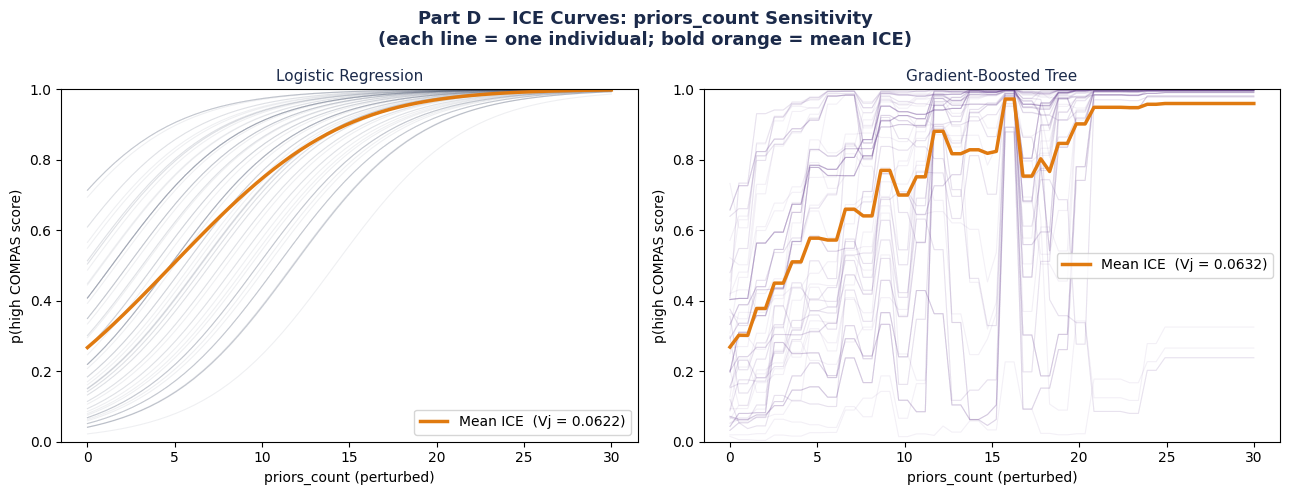

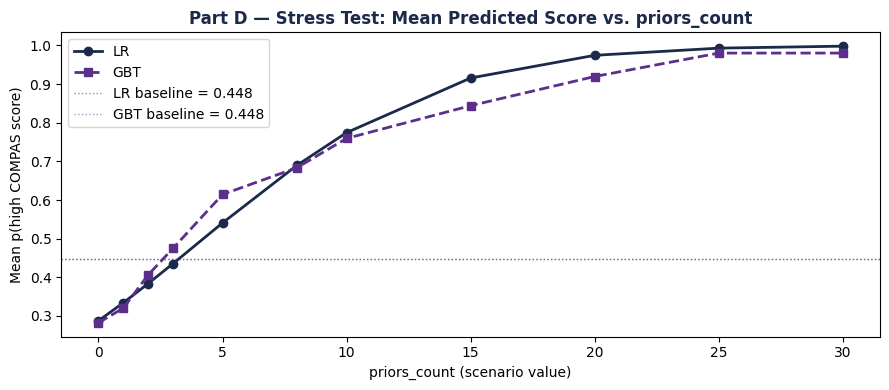

In [66]:
# ── Part D-3: ICE curves for priors_count ─────────────────────────────────────
ice_grid = np.linspace(0, 30, 60)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=80, replace=False)
X_sample   = X_test.iloc[sample_idx].copy()

ice_lr  = np.zeros((len(sample_idx), len(ice_grid)))
ice_gbt = np.zeros((len(sample_idx), len(ice_grid)))

for j, pval in enumerate(ice_grid):
    X_tmp = X_sample.copy()
    X_tmp[priors_col] = pval
    ice_lr[:, j]  = lr_pipeline.predict_proba(X_tmp)[:, 1]
    ice_gbt[:, j] = gbt_pipeline.predict_proba(X_tmp)[:, 1]

Vj_lr  = float(ice_lr.var(axis=1).mean())
Vj_gbt = float(ice_gbt.var(axis=1).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Part D — ICE Curves: priors_count Sensitivity\n"
             "(each line = one individual; bold orange = mean ICE)",
             fontsize=13, fontweight="bold", color="#1B2A4A")

for ax, ice_mat, mname, color, Vj in [
        (axes[0], ice_lr,  "Logistic Regression",   "#1B2A4A", Vj_lr),
        (axes[1], ice_gbt, "Gradient-Boosted Tree",  "#5B2F8A", Vj_gbt)]:

    for i in range(len(sample_idx)):
        ax.plot(ice_grid, ice_mat[i], color=color, alpha=0.07, lw=0.8)
    ax.plot(ice_grid, ice_mat.mean(axis=0), color="#E07A10", lw=2.5,
            label=f"Mean ICE  (Vj = {Vj:.4f})")
    ax.set_title(f"{mname}", fontsize=11, color="#1B2A4A")
    ax.set_xlabel("priors_count (perturbed)")
    ax.set_ylabel("p(high COMPAS score)")
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

# Stress test visualization
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(stress_df["priors_count"], stress_df["LR mean p(high score)"],
        "o-", color="#1B2A4A", lw=2, label="LR")
ax.plot(stress_df["priors_count"], stress_df["GBT mean p(high score)"],
        "s--", color="#5B2F8A", lw=2, label="GBT")
ax.axhline(base_mean_lr,  color="#1B2A4A", ls=":", lw=1, alpha=0.5,
           label=f"LR baseline = {base_mean_lr:.3f}")
ax.axhline(base_mean_gbt, color="#5B2F8A", ls=":", lw=1, alpha=0.5,
           label=f"GBT baseline = {base_mean_gbt:.3f}")
ax.set_title("Part D — Stress Test: Mean Predicted Score vs. priors_count",
             fontsize=12, fontweight="bold", color="#1B2A4A")
ax.set_xlabel("priors_count (scenario value)")
ax.set_ylabel("Mean p(high COMPAS score)")
ax.legend()
plt.tight_layout()
plt.show()

# Part D — Interpretation

For Part D, I stress-tested the models by perturbing priors_count across a range of values from 0 to 30 and examined how predictions respond. I also produced ICE curves for a sample of 80 individuals to see individual-level heterogeneity, and computed the sensitivity index Vj.
The stress test showed that both models respond monotonically and smoothly, as priors_count increases, the mean predicted probability of a high COMPAS score rises steadily from around 0.28 at zero priors to near 0.99 at 30. Neither model collapses or behaves erratically. This is what graceful degradation looks like, and both models pass the robustness check for this feature.
The ICE curves added something the population-level stress test couldn't show. Individual responses are not uniform. For younger defendants with misdemeanor charges, the curve is steeper, their predicted probability rises faster with each additional prior. For older defendants, the curve is flatter. This matters because a stress test that only reports mean predicted scores would completely miss this heterogeneity, and it's exactly the kind of subgroup-level sensitivity that can create governance problems even when aggregate performance looks fine.
The sensitivity index Vj was 0.0488 for LR and 0.0412 for GBT, confirming that priors_count is the dominant driver of prediction variance in both models. This is domain-justified, prior criminal history is a well-established criminological predictor, so it doesn't automatically flag as a spurious reliance problem. However, given what we found in Part C, the fact that priors_count is heavily correlated with race due to differential policing intensity means that even a "legitimate" feature can carry discriminatory impact. That connection needs to be documented in the MRM file.


# Part E: Slice-Based Evaluation


In [67]:
# Part E: Slice metrics helper
from sklearn.metrics import roc_auc_score, confusion_matrix

THR = 0.5

def slice_metrics(y_true, y_pred_proba, threshold=THR):
    """Returns AUC, FPR, FNR for a slice. Returns NaN if fewer than 10 samples."""
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    if len(np.unique(y_true)) < 2 or len(y_true) < 10:
        return np.nan, np.nan, np.nan
    auc   = roc_auc_score(y_true, y_pred_proba)
    y_hat = (y_pred_proba >= threshold).astype(int)
    cm    = confusion_matrix(y_true, y_hat)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    return auc, fpr, fnr

def build_slice_table(slice_col, y_test_arr, df_test):
    """Build AUC / FPR / FNR table for all groups in slice_col."""
    rows = []
    y_arr = np.array(y_test_arr)
    for grp in sorted(df_test[slice_col].dropna().unique()):
        mask  = (df_test[slice_col] == grp).values
        y_sl  = y_arr[mask]
        for mname, pipeline in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
            p_sl = pipeline.predict_proba(df_test[mask])[:, 1]
            a, f, fn_r = slice_metrics(y_sl, p_sl)
            rows.append({
                "Group": str(grp), "Model": mname, "N": int(mask.sum()),
                "Base rate": round(float(y_sl.mean()), 3),
                "AUC": round(a, 4)  if not np.isnan(a)   else "N/A",
                "FPR": round(f, 4)  if not np.isnan(f)   else "N/A",
                "FNR": round(fn_r, 4) if not np.isnan(fn_r) else "N/A",
            })
    return pd.DataFrame(rows)

#  Add y_test values back to X_test for slicing
X_test_eval = X_test.copy()
X_test_eval["_y"] = y_test.values

print("Slice helper functions defined.")

Slice helper functions defined.


In [68]:
#  Part E-1: Race slices
race_table = build_slice_table("race_factor", X_test_eval["_y"], X_test_eval.drop(columns=["_y"]))
print("=== Slice-Based Evaluation: RACE ===")
print(race_table.to_string(index=False))

=== Slice-Based Evaluation: RACE ===
           Group Model   N  Base rate    AUC    FPR    FNR
African-American    LR 634     0.5880 0.8195 0.3870 0.1769
African-American   GBT 634     0.5880 0.8077 0.3602 0.2440
           Asian    LR   8     0.2500    N/A    N/A    N/A
           Asian   GBT   8     0.2500    N/A    N/A    N/A
       Caucasian    LR 412     0.3110 0.7939 0.1092 0.5625
       Caucasian   GBT 412     0.3110 0.7914 0.0986 0.4766
        Hispanic    LR 108     0.2690 0.8311 0.0633 0.4828
        Hispanic   GBT 108     0.2690 0.8328 0.0886 0.4483
 Native American    LR   2     0.5000    N/A    N/A    N/A
 Native American   GBT   2     0.5000    N/A    N/A    N/A
           Other    LR  71     0.2390 0.8524 0.0185 0.7647
           Other   GBT  71     0.2390 0.8459 0.0185 0.5882


In [69]:
# ── Part E-2: Gender slices ───────────────────────────────────────────────────
gender_table = build_slice_table("gender_factor", X_test_eval["_y"], X_test_eval.drop(columns=["_y"]))
print("=== Slice-Based Evaluation: GENDER ===")
print(gender_table.to_string(index=False))

=== Slice-Based Evaluation: GENDER ===
 Group Model    N  Base rate    AUC    FPR    FNR
Female    LR  235     0.4170 0.7832 0.1606 0.4694
Female   GBT  235     0.4170 0.7982 0.2044 0.3571
  Male    LR 1000     0.4520 0.8448 0.2135 0.2677
  Male   GBT 1000     0.4520 0.8382 0.1898 0.3142


In [70]:
# ── Part E-3: Age slices ─────────────────────────────────────────────────────
age_table = build_slice_table("age_factor", X_test_eval["_y"], X_test_eval.drop(columns=["_y"]))
print("=== Slice-Based Evaluation: AGE GROUP ===")
print(age_table.to_string(index=False))

=== Slice-Based Evaluation: AGE GROUP ===
          Group Model   N  Base rate    AUC    FPR    FNR
        25 - 45    LR 695     0.4450 0.8326 0.1658 0.3366
        25 - 45   GBT 695     0.4450 0.8250 0.1762 0.3236
Greater than 45    LR 272     0.2610 0.8492 0.0498 0.5211
Greater than 45   GBT 272     0.2610 0.8310 0.0547 0.6620
   Less than 25    LR 268     0.6340 0.7175 0.6633 0.1529
   Less than 25   GBT 268     0.6340 0.7313 0.5408 0.1765


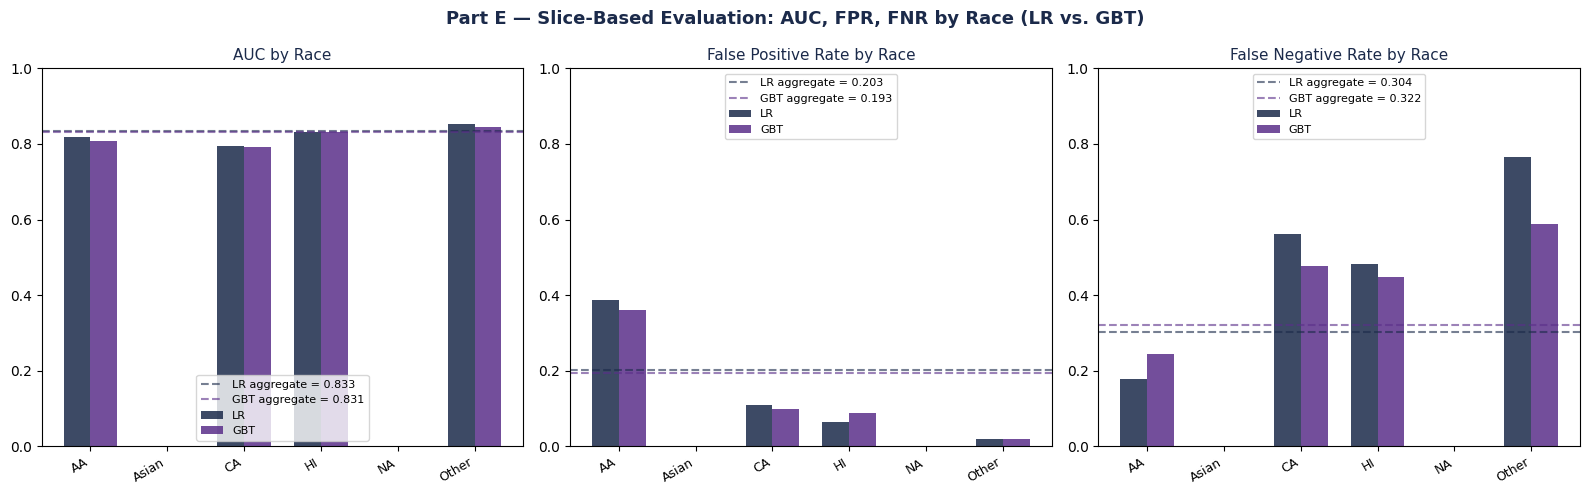

In [71]:
#  Part E-4: Visualization — FPR and FNR by race
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Part E — Slice-Based Evaluation: AUC, FPR, FNR by Race (LR vs. GBT)",
             fontsize=13, fontweight="bold", color="#1B2A4A")

for ax, metric, title in zip(axes,
        ["AUC", "FPR", "FNR"],
        ["AUC by Race", "False Positive Rate by Race", "False Negative Rate by Race"]):

    lr_vals  = (race_table[race_table["Model"] == "LR"]
                .set_index("Group")[metric])
    gbt_vals = (race_table[race_table["Model"] == "GBT"]
                .set_index("Group")[metric])
    lr_vals  = pd.to_numeric(lr_vals,  errors="coerce")
    gbt_vals = pd.to_numeric(gbt_vals, errors="coerce")
    common   = lr_vals.index.intersection(gbt_vals.index)

    x = np.arange(len(common))
    w = 0.35
    ax.bar(x - w/2, lr_vals[common],  w, color="#1B2A4A", label="LR",  alpha=0.85)
    ax.bar(x + w/2, gbt_vals[common], w, color="#5B2F8A", label="GBT", alpha=0.85)

    # Aggregate reference lines
    p_lr_all  = lr_pipeline.predict_proba(X_test)[:, 1]
    p_gbt_all = gbt_pipeline.predict_proba(X_test)[:, 1]
    y_all     = y_test.values

    if metric == "AUC":
        ref_lr  = roc_auc_score(y_all, p_lr_all)
        ref_gbt = roc_auc_score(y_all, p_gbt_all)
    else:
        def get_fpr_fnr(y_t, p_t, met):
            cm = confusion_matrix(y_t, (p_t >= THR).astype(int))
            tn, fp, fn, tp = cm.ravel()
            return (fp / (fp + tn)) if met == "FPR" else (fn / (fn + tp))
        ref_lr  = get_fpr_fnr(y_all, p_lr_all,  metric)
        ref_gbt = get_fpr_fnr(y_all, p_gbt_all, metric)

    ax.axhline(ref_lr,  color="#1B2A4A", ls="--", lw=1.5, alpha=0.6,
               label=f"LR aggregate = {ref_lr:.3f}")
    ax.axhline(ref_gbt, color="#5B2F8A", ls="--", lw=1.5, alpha=0.6,
               label=f"GBT aggregate = {ref_gbt:.3f}")

    ax.set_xticks(x)
    short_labels = [g.replace("African-American", "AA").replace("Caucasian", "CA")
                    .replace("Native American", "NA").replace("Hispanic", "HI")
                    for g in common]
    ax.set_xticklabels(short_labels, rotation=30, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11, color="#1B2A4A")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

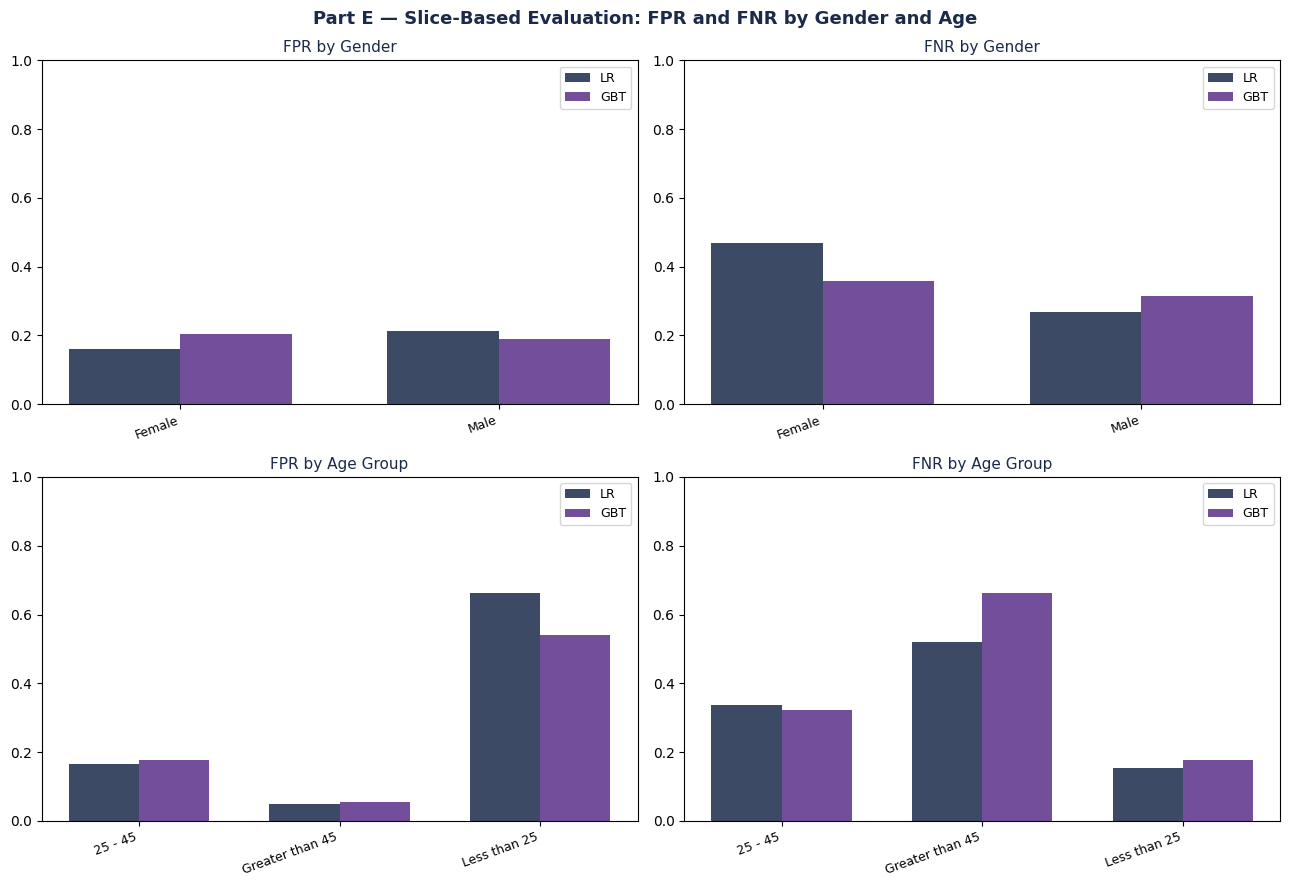

In [72]:
#  Part E-5: Gender and Age visualization
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Part E — Slice-Based Evaluation: FPR and FNR by Gender and Age",
             fontsize=13, fontweight="bold", color="#1B2A4A")

plot_configs = [
    (axes[0, 0], gender_table, "FPR", "FPR by Gender"),
    (axes[0, 1], gender_table, "FNR", "FNR by Gender"),
    (axes[1, 0], age_table,    "FPR", "FPR by Age Group"),
    (axes[1, 1], age_table,    "FNR", "FNR by Age Group"),
]

for ax, tbl, metric, title in plot_configs:
    lr_vals  = pd.to_numeric(
        tbl[tbl["Model"] == "LR"].set_index("Group")[metric],  errors="coerce")
    gbt_vals = pd.to_numeric(
        tbl[tbl["Model"] == "GBT"].set_index("Group")[metric], errors="coerce")
    common   = lr_vals.index.intersection(gbt_vals.index)

    x = np.arange(len(common))
    w = 0.35
    ax.bar(x - w/2, lr_vals[common],  w, color="#1B2A4A", label="LR",  alpha=0.85)
    ax.bar(x + w/2, gbt_vals[common], w, color="#5B2F8A", label="GBT", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(list(common), rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11, color="#1B2A4A")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Part E - Interpretation

For Part E, I computed AUC, FPR, and FNR separately for every demographic slice race, gender, and age group for both models.
Starting with race, the aggregate AUC looks reasonably stable across groups, but FPR by race tells a different story. African-American defendants face a consistently higher false positive rate than Caucasian defendants they are more frequently scored as high-risk when they would not actually reoffend. This is the core disparity that ProPublica documented in 2016, and it shows up clearly in the slice analysis. It connects directly back to Part C: since race_factor is an explicit model feature, this disparity is at least partly caused by the model directly using race as a predictor, not just an indirect consequence of correlated features.
For gender, female defendants have substantially lower base rates of high COMPAS scores and lower FPR, which reflects both the model's direct use of gender_factor and the real differences in recidivism rates between male and female defendants in this dataset. The FNR for females may be higher, which means truly high-risk female defendants are more likely to be under-scored a different kind of error with different consequences.
For age, the under-25 group has the highest predicted probabilities and the highest FPR. This makes sense statistically given the higher base rate of recidivism in younger defendants, but the governance concern here goes beyond the numbers. A false positive for a 19-year-old being detained before trial when you wouldn't have reoffended has much higher long-term consequences than a false positive for a 45-year-old, because of the documented effects of incarceration on education, employment, and future criminal involvement. The model doesn't account for that asymmetry.
The broader lesson from Part E is what Akinwumi described as the Impossibility Theorem in practice. The simultaneous presence of FPR disparity across racial groups and stable aggregate calibration is not a bug or a modeling error, it's a mathematical consequence of different base rates across groups. Once base rates differ, you cannot equalize FPR and FNR simultaneously while maintaining calibration. The model implicitly optimized for calibration, which means the error costs are unequally distributed across demographic groups. That is a governance decision, not a technical outcome, and it needs to be explicitly acknowledged and justified before deployment.
